# Diffuse LiDAR Spatial Calibration — Demo

This notebook demonstrates how to load and use a spatial calibration `.npz` file
produced by our pipeline. It visualizes the per-pixel spatial sensitivity of the
TMF8828 3x3 SPAD sensor overlaid on a reference RGB image.

No hardware required — everything runs from the included calibration files.

In [25]:
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import matplotlib.lines as mlines

## 1. Load the calibration

The `.npz` contains:
- `responses` — shape `(3, 3, K)`: per-pixel response at each of K scan positions
- `xs`, `ys` — shape `(K,)`: retroreflective patch center in the RGB image at each position

In [26]:
CALIB_PATH = Path("calibrations/spad_calib_3x3_longrange_bins15_35.npz")
RGB_PATH = Path("assets/sample_rgb.png")

cal = np.load(CALIB_PATH)
responses = cal["responses"]       # (3, 3, K)
xs = cal["xs"].astype(np.float32)  # (K,)
ys = cal["ys"].astype(np.float32)  # (K,)

Sy, Sx, K = responses.shape
print(f"Sensor grid: {Sy}x{Sx} = {Sy*Sx} pixels")
print(f"Scan positions: {K}")

bg_img = np.array(Image.open(RGB_PATH).convert("RGB")).astype(np.float32) / 255.0
H, W = bg_img.shape[:2]
print(f"RGB image: {W}x{H}")

Sensor grid: 3x3 = 9 pixels
Scan positions: 3600
RGB image: 848x480


## 2. Per-pixel response maps

Each SPAD pixel has a spatial sensitivity pattern — its "footprint" in the RGB image.
Below we show all 9 pixels in the sensor's native array order. Bright points = strong
response when the retroreflective patch was at that position.

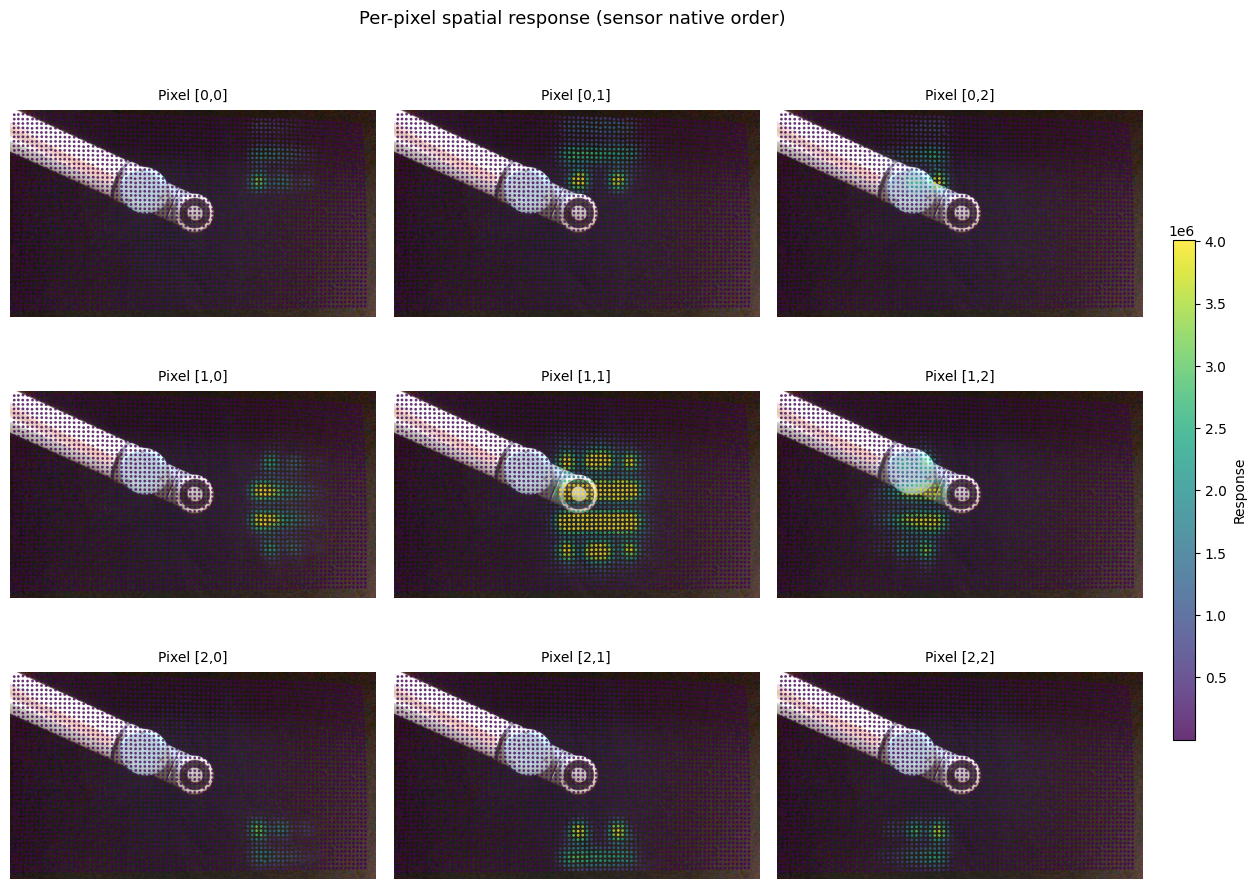

In [27]:
vals_all = responses.astype(np.float32)
vmin = float(np.percentile(vals_all[np.isfinite(vals_all)], 1))
vmax = float(np.percentile(vals_all[np.isfinite(vals_all)], 99.5))

fig, axes = plt.subplots(Sy, Sx, figsize=(15, 10),
                         gridspec_kw={"hspace": 0.35, "wspace": 0.05,
                                      "right": 0.88})

for row in range(Sy):
    for col in range(Sx):
        ax = axes[row, col]
        ax.imshow(bg_img)
        vals = responses[row, col, :]
        sc = ax.scatter(xs, ys, c=vals, s=4, vmin=vmin, vmax=vmax,
                        alpha=0.8, linewidths=0)
        ax.set_title(f"Pixel [{row},{col}]", fontsize=10, pad=8)
        ax.set_axis_off()

cax = fig.add_axes([0.90, 0.25, 0.015, 0.5])
fig.colorbar(sc, cax=cax, label="Response")
fig.suptitle("Per-pixel spatial response (sensor native order)", fontsize=13, y=0.98)
plt.show()

**Note on pixel ordering:** The TMF8828's pixel grid is left-right mirrored
relative to the camera. Notice that pixel `[0,0]` (top-left subplot) responds to the
**right** side of the image, while `[0,2]` (top-right subplot) responds to the **left**.

```
Sensor array:              Corresponding camera view:
  [0,0]  [0,1]  [0,2]       [0,2]  [0,1]  [0,0]
  [1,0]  [1,1]  [1,2]       [1,2]  [1,1]  [1,0]
  [2,0]  [2,1]  [2,2]       [2,2]  [2,1]  [2,0]
```

This doesn't affect calibration correctness — the response data maps each pixel to the
correct (x, y) positions regardless. The combined overlay below flips columns at display
time so the color labels read left-to-right in the camera's frame.

## 3. Combined overlay

All 9 pixels composited with unique colors onto the RGB image. Each color represents
one SPAD pixel's spatial sensitivity. This is the main calibration visualization from
the paper.

In [28]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

MAX_ALPHA = 0.90
ALPH_THRESH = 0.025
DOT_SIZE = 22
BG_DARKEN = 0.7


def normalize(vals, vmin, vmax):
    out = (vals.astype(np.float32) - vmin) / max(vmax - vmin, 1e-8)
    out[~np.isfinite(out)] = 0.0
    return np.clip(out, 0.0, 1.0)


def render_scatter(xs, ys, rgba, H, W, dot_size, dpi=150):
    fig = plt.Figure(figsize=(W / dpi, H / dpi), dpi=dpi)
    canvas = FigureCanvas(fig)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_axis_off(); ax.set_facecolor((0, 0, 0, 0))
    fig.patch.set_alpha(0.0)
    ax.scatter(xs, ys, s=dot_size, c=rgba, linewidths=0)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba(), dtype=np.float32) / 255.0


P = Sy * Sx
cmap = plt.get_cmap("hsv")
colors = [cmap(i / max(1, P)) for i in range(P)]

C_sum = np.zeros((H, W, 3), dtype=np.float32)
A_sum = np.zeros((H, W), dtype=np.float32)

k = 0
for py in range(Sy):
    for col in range(Sx):
        px = (Sx - 1) - col  # flip for camera view
        vals = vals_all[py, px, :]
        u = normalize(vals, vmin, vmax)

        rgba = np.tile(np.array(to_rgba(colors[k]), dtype=np.float32), (K, 1))
        alpha = (u * MAX_ALPHA).astype(np.float32)
        alpha[alpha < ALPH_THRESH] = 0.0
        rgba[:, 3] = alpha

        layer = render_scatter(xs, ys, rgba, H, W, DOT_SIZE)
        a = layer[..., 3]
        C_sum += layer[..., :3] * a[..., None]
        A_sum += a
        k += 1
        print(f"  Rendered pixel {k}/{P}", end="\r")

C_out = C_sum / np.maximum(A_sum[..., None], 1e-8)
A_out = np.clip(1.0 - np.exp(-A_sum), 0.0, 1.0)
print(f"Done: composited {P} pixel layers.")

Done: composited 9 pixel layers.


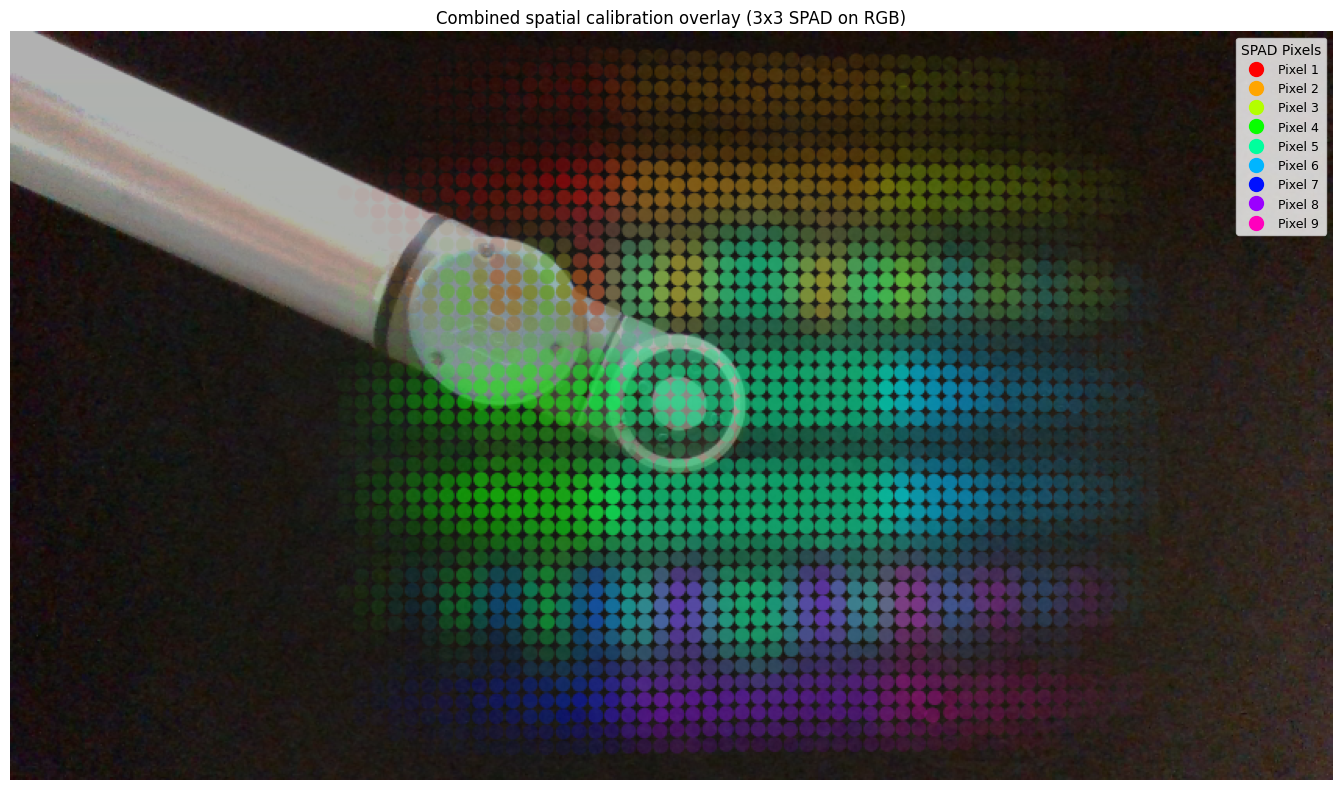

In [29]:
bg_disp = np.clip(bg_img * BG_DARKEN, 0, 1)
out = C_out * A_out[..., None] + bg_disp * (1 - A_out[..., None])

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.imshow(np.clip(out, 0, 1))
ax.set_axis_off()

legend_handles = [
    mlines.Line2D([], [], color=colors[i], marker="o", linestyle="None",
                  markersize=10, label=f"Pixel {i + 1}")
    for i in range(P)
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9,
          framealpha=0.8, title="SPAD Pixels")
ax.set_title("Combined spatial calibration overlay (3x3 SPAD on RGB)")
plt.tight_layout()
plt.show()

## 4. Using the calibration in your own code

```python
import numpy as np

cal = np.load("calibrations/spad_calib_3x3_longrange_bins15_35.npz")
responses = cal["responses"]  # (3, 3, K)
xs = cal["xs"]                # (K,) x-coords in RGB image
ys = cal["ys"]                # (K,) y-coords in RGB image

# Get the spatial sensitivity map for a specific pixel
row, col = 1, 1  # center pixel (sensor native index)
sensitivity = responses[row, col, :]  # (K,) response at each scan position

# Each (xs[k], ys[k]) tells you WHERE in the camera image
# that response value was measured
```